=== VISA/MASTERCARD PHOENIX AUTOCALLABLE PRICER ===

S0_V = 303.33
S0_MA = 501.50
sigma_V = 21.2%
sigma_MA = 21.1%
Correlation = 0.875

=== PRICING RESULTS ===
price: 0.9764
knockin_prob: 0.6948
delta_V: 0.0030
delta_M: 0.0018
gamma_V: -0.0006
gamma_M: -0.0002
vega: -0.2868
corr_sens: 0.0750

Generating plots...


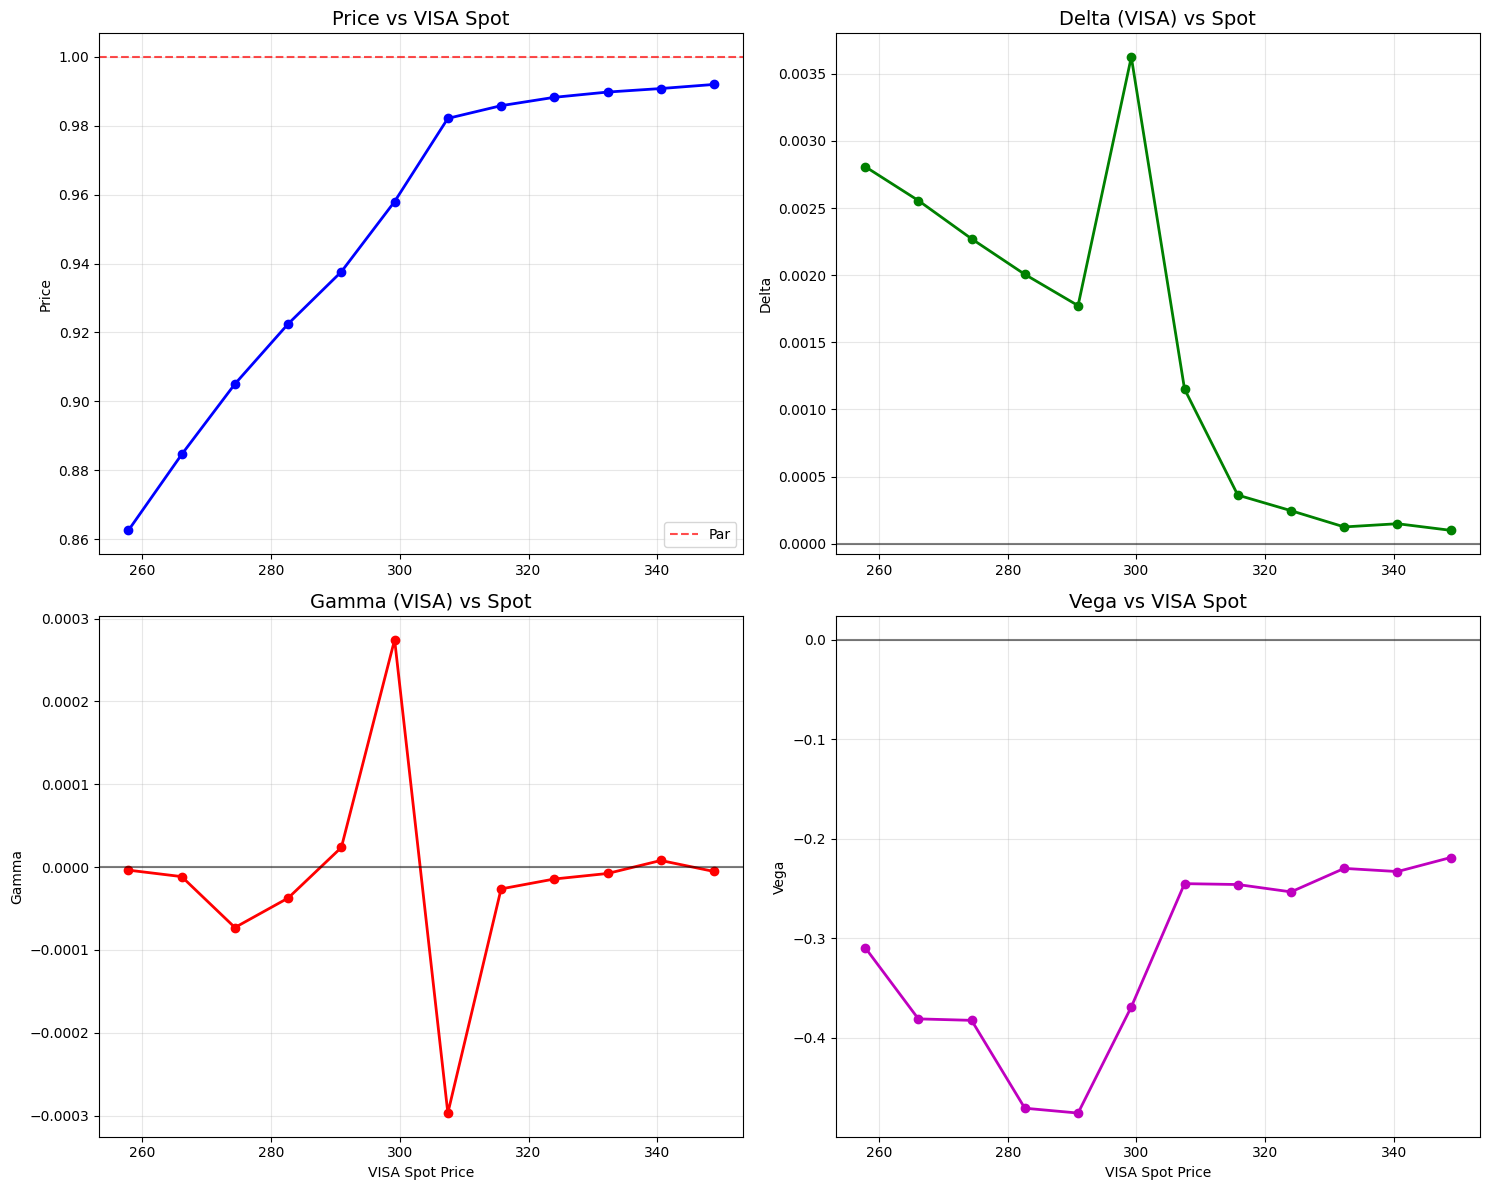

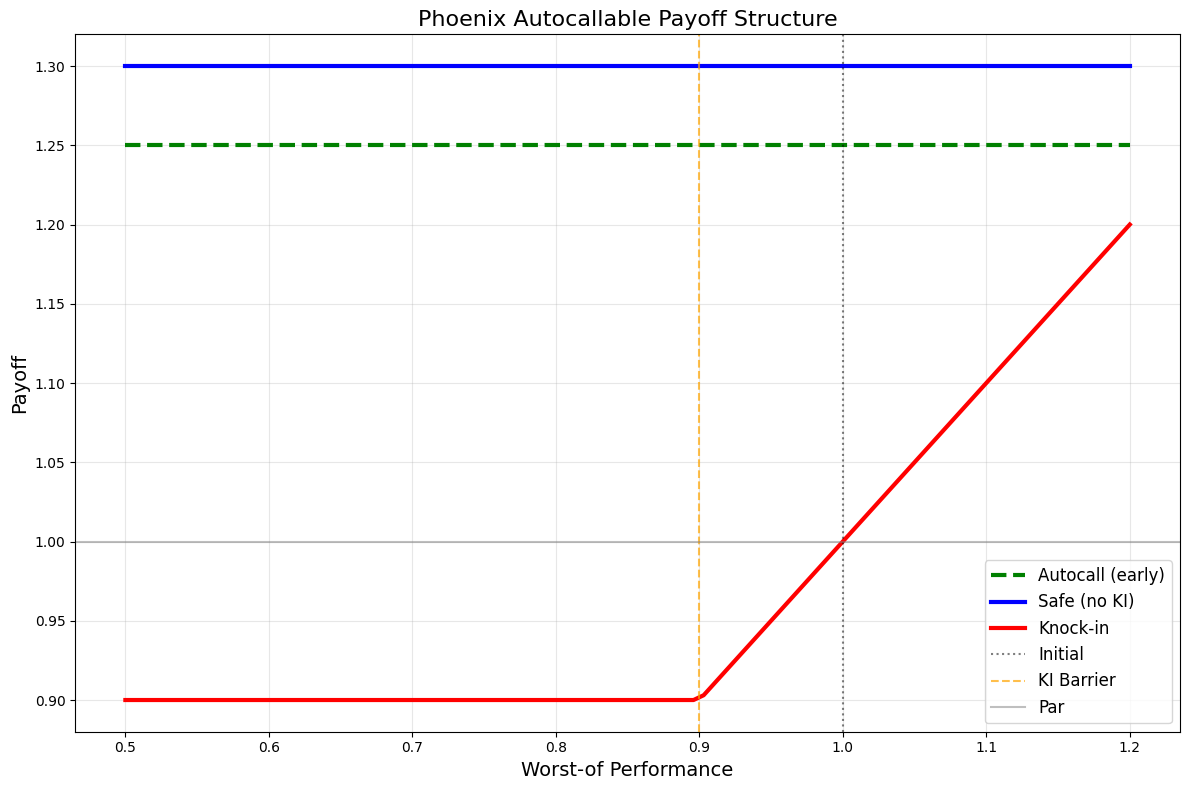

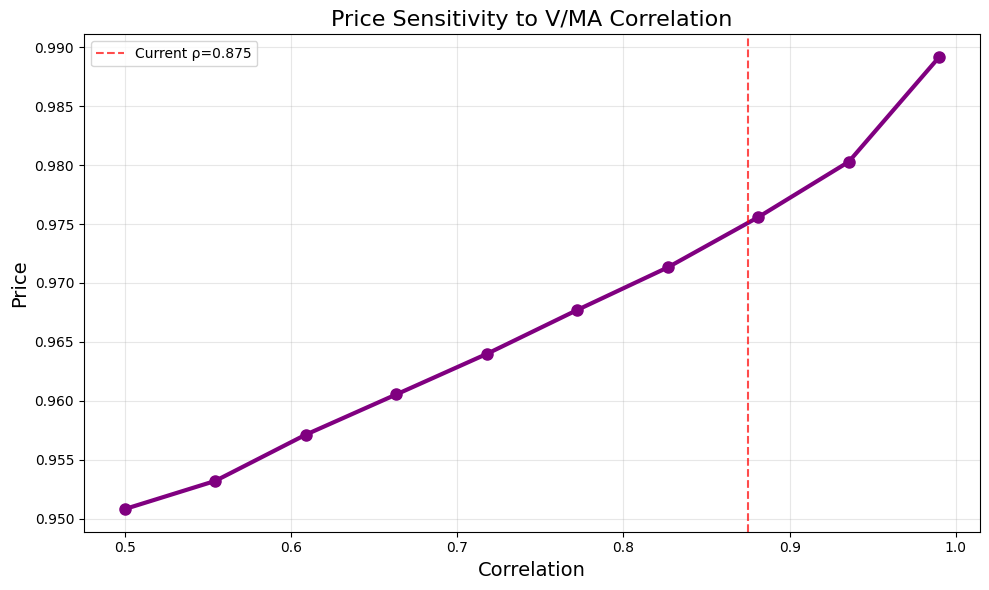


=== PLOTS SAVED ===
- output/greeks_plots.png (Delta/Gamma/Vega vs Spot)
- output/payoff_diagram.png
- output/corr_sensitivity.png
- output/greeks_vs_spot.csv
- output/corr_sensitivity.csv


In [29]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import os

# Create output directory
os.makedirs("output", exist_ok=True)

print("=== VISA/MASTERCARD PHOENIX AUTOCALLABLE PRICER ===\n")

# ==========================================
# 1. MARKET DATA (Yahoo Finance)
# ==========================================
data = yf.download(["V", "MA"], period="2y", auto_adjust=True, progress=False)["Close"].dropna()
S0_V = float(data["V"].iloc[-1])
S0_MA = float(data["MA"].iloc[-1])
print(f"S0_V = {S0_V:.2f}")
print(f"S0_MA = {S0_MA:.2f}")

rets = np.log(data / data.shift(1)).dropna()
sigma_V = rets["V"].std() * np.sqrt(252)
sigma_MA = rets["MA"].std() * np.sqrt(252)
rho = rets["V"].corr(rets["MA"])
print(f"sigma_V = {sigma_V:.1%}")
print(f"sigma_MA = {sigma_MA:.1%}")
print(f"Correlation = {rho:.3f}")

# ==========================================
# 2. PRODUCT PARAMETERS
# ==========================================
S0_orig = np.array([S0_V, S0_MA])          # original spot at issuance (fixed for barriers)
vols = np.array([sigma_V, sigma_MA])
q = np.array([0.0068, 0.0055])             # dividend yields

r = 0.0431                                 # 3Y Treasury proxy
T = 3.0                                    # 3 years
n_obs = 12                                 # quarterly observations
dt = 1/252                                 # daily steps
n_paths = 50000                            # for final price (reduce for plots)
coupon_rate = 0.10                         # 10% annual
autocall_barrier = 1.00                    # 100%
knock_in_barrier = 0.90                    # 90% (quarterly monitored)

seed = 42

# ==========================================
# 3. CORRECTED PRICING ENGINE
# ==========================================

def generate_paths(S0, vols, rho, r, q, T, dt, n_paths, seed=None):
    """Generate correlated GBM paths with dividends."""
    if seed is not None:
        np.random.seed(seed)
    n_steps = int(T / dt)
    L = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]]))
    Z = np.random.normal(size=(2, n_steps, n_paths))
    Zc = np.einsum("ij,jkl->ikl", L, Z)
    paths = np.zeros((2, n_steps + 1, n_paths))
    paths[:, 0, :] = S0.reshape(-1, 1)
    drift = (r - q - 0.5 * vols**2) * dt
    diffusion = vols * np.sqrt(dt)
    for t in range(1, n_steps + 1):
        expo = drift.reshape(-1, 1) + diffusion.reshape(-1, 1) * Zc[:, t - 1, :]
        paths[:, t, :] = paths[:, t - 1, :] * np.exp(expo)
    return paths

def price_phoenix(paths, S0_orig, S0_bumped, autocall_barrier, knock_in_barrier, coupon_rate, r, T, n_obs):
    """
    paths: (2, n_steps+1, n_paths) - generated using S0_bumped as starting point
    S0_orig: original spot at issuance (used to compute absolute barriers)
    S0_bumped: the spot used to generate paths (for delta/gamma, this is bumped)
    Barriers are absolute: autocall_level = autocall_barrier * min(S0_orig)
    knock_in_level = knock_in_barrier * min(S0_orig)  (worst-of product)
    """
    n_paths = paths.shape[2]
    n_steps = paths.shape[1] - 1

    # Relative to original spot (for barrier checks)
    rel_to_orig = paths / S0_orig.reshape(-1, 1, 1)   # shape (2, n_steps+1, n_paths)
    worst_of = np.min(rel_to_orig, axis=0)            # (n_steps+1, n_paths)

    # Quarterly observation indices
    obs_indices = np.linspace(1, n_steps, n_obs, dtype=int)

    # Knock-in monitored only at quarterly dates
    knocked_in = np.any(worst_of[obs_indices, :] < knock_in_barrier, axis=0)

    alive = np.ones(n_paths, dtype=bool)
    payoffs_pv = np.zeros(n_paths)

    dt_obs = T / n_obs
    for i, t in enumerate(obs_indices, 1):
        active = np.where(alive)[0]
        if len(active) == 0:
            break
        trigger = worst_of[t, active] >= autocall_barrier
        if np.any(trigger):
            idx = active[trigger]
            tau = i * dt_obs
            payoff = 1.0 + coupon_rate * tau
            payoffs_pv[idx] = payoff * np.exp(-r * tau)
            alive[idx] = False

    # Maturity payoff
    final_idx = np.where(alive)[0]
    if len(final_idx) > 0:
        final_worst = worst_of[-1, final_idx]
        final_ki = knocked_in[final_idx]
        payoff_ki = final_worst
        payoff_safe = 1.0 + coupon_rate * T
        terminal_payoff = np.where(final_ki, payoff_ki, payoff_safe)
        payoffs_pv[final_idx] = terminal_payoff * np.exp(-r * T)

    return payoffs_pv.mean(), knocked_in.mean()

# ==========================================
# 4. GREEKS CALCULATION (ORIGINAL SPOT)
# ==========================================

def calculate_greeks(S0_orig, vols, rho, r, q, T, dt, n_obs, coupon_rate, barriers, n_paths, seed=42):
    """Finite difference Greeks with common random numbers.
       Barriers are fixed using S0_orig; current spot = S0_orig."""
    eps_S = S0_orig * 0.015
    eps_vol = 0.01
    eps_rho = 0.01

    # Base price
    paths_base = generate_paths(S0_orig, vols, rho, r, q, T, dt, n_paths, seed=seed)
    price_base, ki_base = price_phoenix(paths_base, S0_orig, S0_orig,
                                        barriers[0], barriers[1], coupon_rate, r, T, n_obs)

    # Delta VISA
    S_up_V = S0_orig.copy(); S_up_V[0] += eps_S[0]
    S_dn_V = S0_orig.copy(); S_dn_V[0] -= eps_S[0]
    p_up_V, _ = price_phoenix(generate_paths(S_up_V, vols, rho, r, q, T, dt, n_paths, seed=seed),
                              S0_orig, S_up_V, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    p_dn_V, _ = price_phoenix(generate_paths(S_dn_V, vols, rho, r, q, T, dt, n_paths, seed=seed),
                              S0_orig, S_dn_V, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    delta_V = (p_up_V - p_dn_V) / (2 * eps_S[0])
    gamma_V = (p_up_V - 2*price_base + p_dn_V) / (eps_S[0]**2)

    # Delta MA
    S_up_M = S0_orig.copy(); S_up_M[1] += eps_S[1]
    S_dn_M = S0_orig.copy(); S_dn_M[1] -= eps_S[1]
    p_up_M, _ = price_phoenix(generate_paths(S_up_M, vols, rho, r, q, T, dt, n_paths, seed=seed),
                              S0_orig, S_up_M, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    p_dn_M, _ = price_phoenix(generate_paths(S_dn_M, vols, rho, r, q, T, dt, n_paths, seed=seed),
                              S0_orig, S_dn_M, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    delta_M = (p_up_M - p_dn_M) / (2 * eps_S[1])
    gamma_M = (p_up_M - 2*price_base + p_dn_M) / (eps_S[1]**2)

    # Vega
    vols_up = vols + eps_vol
    p_vol_up, _ = price_phoenix(generate_paths(S0_orig, vols_up, rho, r, q, T, dt, n_paths, seed=seed),
                                S0_orig, S0_orig, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    vega = (p_vol_up - price_base) / eps_vol

    # Correlation sensitivity
    rho_up = min(rho + eps_rho, 0.99)
    p_rho_up, _ = price_phoenix(generate_paths(S0_orig, vols, rho_up, r, q, T, dt, n_paths, seed=seed),
                                S0_orig, S0_orig, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    corr_sens = (p_rho_up - price_base) / eps_rho

    return {
        "price": price_base,
        "knockin_prob": ki_base,
        "delta_V": delta_V, "delta_M": delta_M,
        "gamma_V": gamma_V, "gamma_M": gamma_M,
        "vega": vega, "corr_sens": corr_sens
    }

# ==========================================
# 5. HELPER FOR GREEKS AT ARBITRARY CURRENT SPOT
# ==========================================

def calculate_greeks_at_spot(S_curr, S0_orig, vols, rho, r, q, T, dt, n_obs, coupon_rate, barriers, n_paths, seed=42):
    """Compute price and Greeks for a given current spot S_curr,
       while keeping barriers fixed at original levels (based on S0_orig)."""
    eps_S = S_curr * 0.015
    eps_vol = 0.01
    eps_rho = 0.01

    paths_base = generate_paths(S_curr, vols, rho, r, q, T, dt, n_paths, seed=seed)
    price_base, ki_base = price_phoenix(paths_base, S0_orig, S_curr,
                                        barriers[0], barriers[1], coupon_rate, r, T, n_obs)

    # Delta VISA
    S_up_V = S_curr.copy(); S_up_V[0] += eps_S[0]
    S_dn_V = S_curr.copy(); S_dn_V[0] -= eps_S[0]
    p_up_V, _ = price_phoenix(generate_paths(S_up_V, vols, rho, r, q, T, dt, n_paths, seed=seed),
                              S0_orig, S_up_V, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    p_dn_V, _ = price_phoenix(generate_paths(S_dn_V, vols, rho, r, q, T, dt, n_paths, seed=seed),
                              S0_orig, S_dn_V, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    delta_V = (p_up_V - p_dn_V) / (2 * eps_S[0])
    gamma_V = (p_up_V - 2*price_base + p_dn_V) / (eps_S[0]**2)

    # Delta MA
    S_up_M = S_curr.copy(); S_up_M[1] += eps_S[1]
    S_dn_M = S_curr.copy(); S_dn_M[1] -= eps_S[1]
    p_up_M, _ = price_phoenix(generate_paths(S_up_M, vols, rho, r, q, T, dt, n_paths, seed=seed),
                              S0_orig, S_up_M, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    p_dn_M, _ = price_phoenix(generate_paths(S_dn_M, vols, rho, r, q, T, dt, n_paths, seed=seed),
                              S0_orig, S_dn_M, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    delta_M = (p_up_M - p_dn_M) / (2 * eps_S[1])
    gamma_M = (p_up_M - 2*price_base + p_dn_M) / (eps_S[1]**2)

    # Vega (parallel vol shift)
    vols_up = vols + eps_vol
    p_vol_up, _ = price_phoenix(generate_paths(S_curr, vols_up, rho, r, q, T, dt, n_paths, seed=seed),
                                S0_orig, S_curr, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    vega = (p_vol_up - price_base) / eps_vol

    # Correlation sensitivity
    rho_up = min(rho + eps_rho, 0.99)
    p_rho_up, _ = price_phoenix(generate_paths(S_curr, vols, rho_up, r, q, T, dt, n_paths, seed=seed),
                                S0_orig, S_curr, barriers[0], barriers[1], coupon_rate, r, T, n_obs)
    corr_sens = (p_rho_up - price_base) / eps_rho

    return {
        "price": price_base,
        "knockin_prob": ki_base,
        "delta_V": delta_V, "delta_M": delta_M,
        "gamma_V": gamma_V, "gamma_M": gamma_M,
        "vega": vega, "corr_sens": corr_sens
    }

# ==========================================
# 6. PLOTTING FUNCTIONS
# ==========================================

def plot_greeks_vs_spot(S0_orig, vols, rho, r, q, T, dt, n_obs, coupon_rate, barriers, n_paths=20000):
    """Plot Delta, Gamma, Vega vs VISA spot (barriers anchored to S0_orig)."""
    spot_range = np.linspace(0.85, 1.15, 12) * S0_orig[0]  # 85%-115% of original V spot
    results = []

    for spot_V in spot_range:
        S_curr = np.array([spot_V, S0_orig[1]])  # MA spot stays at original
        greeks = calculate_greeks_at_spot(S_curr, S0_orig, vols, rho, r, q, T, dt, n_obs,
                                          coupon_rate, barriers, n_paths, seed=42)
        results.append({
            'spot_V': spot_V,
            'price': greeks['price'],
            'delta_V': greeks['delta_V'],
            'gamma_V': greeks['gamma_V'],
            'vega': greeks['vega']
        })

    df = pd.DataFrame(results)
    df.to_csv('output/greeks_vs_spot.csv', index=False)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    axes[0,0].plot(df['spot_V'], df['price'], 'b-o', linewidth=2, markersize=6)
    axes[0,0].axhline(y=1.0, color='r', linestyle='--', alpha=0.7, label='Par')
    axes[0,0].set_title('Price vs VISA Spot', fontsize=14)
    axes[0,0].set_ylabel('Price')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].legend()

    axes[0,1].plot(df['spot_V'], df['delta_V'], 'g-o', linewidth=2, markersize=6)
    axes[0,1].axhline(y=0, color='k', alpha=0.5)
    axes[0,1].set_title('Delta (VISA) vs Spot', fontsize=14)
    axes[0,1].set_ylabel('Delta')
    axes[0,1].grid(True, alpha=0.3)

    axes[1,0].plot(df['spot_V'], df['gamma_V'], 'r-o', linewidth=2, markersize=6)
    axes[1,0].axhline(y=0, color='k', alpha=0.5)
    axes[1,0].set_title('Gamma (VISA) vs Spot', fontsize=14)
    axes[1,0].set_ylabel('Gamma')
    axes[1,0].set_xlabel('VISA Spot Price')
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(df['spot_V'], df['vega'], 'm-o', linewidth=2, markersize=6)
    axes[1,1].axhline(y=0, color='k', alpha=0.5)
    axes[1,1].set_title('Vega vs VISA Spot', fontsize=14)
    axes[1,1].set_ylabel('Vega')
    axes[1,1].set_xlabel('VISA Spot Price')
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('output/greeks_plots.png', dpi=300, bbox_inches='tight')
    plt.show()
    return df

def plot_payoff_diagram():
    """Illustrative payoff diagram."""
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    perf = np.linspace(0.5, 1.2, 100)
    autocall_payoff = np.ones_like(perf) + 0.10 * 2.5
    ki_payoff = np.maximum(perf, 0.90)
    safe_payoff = np.ones_like(perf) + 0.10 * 3.0

    ax.plot(perf, autocall_payoff, 'g--', linewidth=3, label='Autocall (early)')
    ax.plot(perf, safe_payoff, 'b-', linewidth=3, label='Safe (no KI)')
    ax.plot(perf, ki_payoff, 'r-', linewidth=3, label='Knock-in')
    ax.axvline(x=1.0, color='k', alpha=0.5, linestyle=':', label='Initial')
    ax.axvline(x=0.90, color='orange', alpha=0.7, linestyle='--', label='KI Barrier')
    ax.axhline(y=1.0, color='gray', alpha=0.5, linestyle='-', label='Par')

    ax.set_xlabel('Worst-of Performance', fontsize=14)
    ax.set_ylabel('Payoff', fontsize=14)
    ax.set_title('Phoenix Autocallable Payoff Structure', fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('output/payoff_diagram.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_correlation_sensitivity(S0_orig, vols, r, q, T, dt, n_obs, coupon_rate, barriers, n_paths=10000):
    """Correlation sensitivity plot (barriers anchored to S0_orig)."""
    rho_range = np.linspace(0.5, 0.99, 10)
    prices = []

    for test_rho in rho_range:
        paths = generate_paths(S0_orig, vols, test_rho, r, q, T, dt, n_paths, seed=42)
        price, _ = price_phoenix(paths, S0_orig, S0_orig,
                                 barriers[0], barriers[1], coupon_rate, r, T, n_obs)
        prices.append(price)

    df_rho = pd.DataFrame({'rho': rho_range, 'price': prices})
    df_rho.to_csv('output/corr_sensitivity.csv', index=False)

    plt.figure(figsize=(10, 6))
    plt.plot(df_rho['rho'], df_rho['price'], 'purple', marker='o', linewidth=3, markersize=8)
    plt.xlabel('Correlation', fontsize=14)
    plt.ylabel('Price', fontsize=14)
    plt.title('Price Sensitivity to V/MA Correlation', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.axvline(x=rho, color='r', linestyle='--', alpha=0.7, label=f'Current ρ={rho:.3f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig('output/corr_sensitivity.png', dpi=300, bbox_inches='tight')
    plt.show()

# ==========================================
# 7. EXECUTE PRICING AND PLOTS
# ==========================================

barriers = (autocall_barrier, knock_in_barrier)

print("\n=== PRICING RESULTS ===")
greeks = calculate_greeks(S0_orig, vols, rho, r, q, T, dt, n_obs, coupon_rate, barriers, n_paths, seed)
for k, v in greeks.items():
    print(f"{k}: {v:.4f}")

# Save results
results = pd.DataFrame([greeks])
results.to_csv("output/phoenix_results.csv", index=False)

print("\nGenerating plots...")
# Use lower number of paths for faster sensitivity plots
plot_greeks_vs_spot(S0_orig, vols, rho, r, q, T, dt, n_obs, coupon_rate, barriers, n_paths=20000)
plot_payoff_diagram()
plot_correlation_sensitivity(S0_orig, vols, r, q, T, dt, n_obs, coupon_rate, barriers, n_paths=10000)

print("\n=== PLOTS SAVED ===")
print("- output/greeks_plots.png (Delta/Gamma/Vega vs Spot)")
print("- output/payoff_diagram.png")
print("- output/corr_sensitivity.png")
print("- output/greeks_vs_spot.csv")
print("- output/corr_sensitivity.csv")